# Deliverable 2: Bayesian Spatial Search Problem
**University of Barcelona**
**Bayesian Statistics and Probabilistic Programming**

---

## Overview

We construct a Bayesian model for recovering lost objects at the sea.
First we start buiding a **prior distribution** over the cells of the grid from objective knowledge of the accident (explosion point, velocity, wind and drift) and two witness statements.
After this, we define a **detection probability** model based on the previous mission reports, we run three search missions, update the beliefs sequentially and propose a **final new search mission**.

---

## 0. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import multivariate_normal, chi2

# Reproducibility
np.random.seed(42)

# Fixed problem constraints
Nx, Ny = 50, 35 # grid dimensions
BUDGET = 230 # how much can be spent on the search

# Accident information (given in the initial notebook)
x_E = np.array([7.0, 20.0]) # explosion point
v_plane = np.array([6.0, -3.5]) # aircraft velocity
v_wind = np.array([-1.0, -1.5]) # wind vector
v_drift = np.array([0.5, -1.5]) # water drift/current

# Grid dataset
grid_df = pd.read_csv("grid_dataset.csv")
print(f"Grid: {grid_df.shape[0]} cells ({Nx}x{Ny})")
grid_df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'grid_dataset.csv'

---

## Task 1: Prior distributions

### Physical motivation

The object fell from the aircraft at the explosion point $\mathbf{x}_E = (7, 20)$.
Two phases affect the object before it rests on the seafloor, acting in sequence.

---

**Phase 1: Aerial drift**. After the object is detached from the airplane, it first carries the full horizontal momentum of the aircraft so its initial horizontal velocity is $\mathbf{v}_{\text{plane}}$. While the object is in the air, it is also subject to the aerodynamic drag from the surrounding air mass, which moves at $\mathbf{v}_{\text{wind}}$. The drag force points opposite to the relative velocity between the object and the air, and is proportional to its magnitude:

$$\mathbf{F}_{\text{drag}} = -\frac{m}{\tau}\bigl(\mathbf{v}(t) - \mathbf{v}_{\text{wind}}\bigr),$$

where $m$ is the object's mass and $\tau$ is the drag timescale; a single number that absorbs the object's shape, size, mass and air density. Large $\tau$ means weak drag (heavy, smooth object), while small $\tau$ means strong drag (light object).

Applying Newton's second law:

$$\text{m} \dot{\text{v}} = \text{F}_\text{drag} = - \tfrac{m}{\tau}\ (\text{v(t)} - \text{v}_\text{wind}).$$

And dividing by $\text{m}$:

$$\dot{\text{v}} = - \tfrac{1}{\tau}\ (\text{v(t)} - \text{v}_\text{wind}).$$

Defining $\mathbf{u}(t) = \mathbf{v}(t) - \mathbf{v}_{\text{wind}}$ (velocity relative to the wind). Then $\dot{\mathbf{u}} = \dot{\mathbf{v}}$, so the equation becomes:

$$\dot{\mathbf{u}} = -\frac{1}{\tau}\,\mathbf{u},$$

This is exponential decay. Its solution is:

$$\mathbf{u}(t) = \mathbf{u}(0)\,e^{-t/\tau}, \qquad \text{i.e.} \qquad \mathbf{v}(t) = \mathbf{v}_{\text{wind}} + \bigl(\mathbf{v}_{\text{plane}} - \mathbf{v}_{\text{wind}}\bigr)e^{-t/\tau}.$$

At $t = 0$, $\mathbf{v} = \mathbf{v}_{\text{plane}}$ (the object carries the aircraft's velocity). As $t \to \infty$, $\mathbf{v} \to \mathbf{v}_{\text{wind}}$ (the drag has fully coupled the object to the air). The timescale over which this happens it $\tau$.

We will suppose that the fall duration is $T_{\text{air}} \ll \tau$ (heavy object, short fall, the object hits the water before the drag has much effect). In this case, the exponential can be approximated by its first-order Taylor expansion $e^{-t/\tau} \approx 1 - t/\tau$, giving:

$$\mathbf{v}(t)≈\mathbf{v}_{wind}​+(\mathbf{v}_{plane​}−\mathbf{v}_{wind}​)(1−\frac{t}{\tau}​).$$

Integrating to get the displacement:

$$\Delta\mathbf{x}_{\text{air}}
= \int_0^{T_{\text{air}}} {\mathbf{v(t)}}\,dt
\approx \mathbf{v}_{\text{plane}}\,T_{\text{air}}
  + \tfrac{1}{2}\,\bigl(\mathbf{v}_{\text{wind}} - \mathbf{v}_{\text{plane}}\bigr)\,\frac{T_{\text{air}}^2}{\tau}.$$

Because $T_{\text{air}}/\tau \ll 1$, the second term is small relative to the first.
Writing the effective wind contribution as
$w_{\text{wind}}\,\mathbf{v}_{\text{wind}}\,T_{\text{air}}$ and absorbing everything into
the weights, the wind contribution is *at most* $\tfrac{T_{\text{air}}}{2\tau}$ times the
plane contribution. Strictly less than the plane's, and strictly positive.

---

**Phase 2: Aquatic drift**. After impact with the water, the object floats while the current carries it at $\mathbf{v}_{\text{drift}}$
for a duration $T_{\text{drift}}$ before sinking. By the same drag-coupling argument (now between the object and the water), the effective drift displacement is:

$$\Delta\mathbf{x}_{\text{drift}} \approx \mathbf{v}_{\text{drift}}\,T_{\text{drift}}.$$

Here we don't have any ½ factor because we assume that the object hits the water still moving fast horizontally at roughly $\mathbf{v}_{\text{plane}}$, which is much larger than $\mathbf{v}_{\text{drift}}$. Water drag is strong (water density is ~800x air), so $\tau_{\text{water}} \ll T_{\text{drift}}$, meaning the object couples to the drift velocity quickly. Once coupled, it moves at $\mathbf{v}_{\text{drift}}$ for a remainder of $T_{\text{drift}}$, so the full drift velocity applies for most of the phase. The ½ does not appear because the coupling happens fast at the *start* of the phase, not gradually throughout it.

---

### Weight assignment

From the displacement integrals derived, the total expected displacement is:

$$\Delta\mathbf{x} = \Delta\mathbf{x}_{\text{air}} + \Delta\mathbf{x}_{\text{drift}} \approx \mathbf{v}_{\text{plane}}\,T_{\text{air}} + \frac{1}{2}\bigl(\mathbf{v}_{\text{wind}} - \mathbf{v}_{\text{plane}}\bigr)\frac{T_{\text{air}}^2}{\tau} + \mathbf{v}_{\text{drift}}\,T_{\text{drift}}.$$

We want to write this in the form $w_{\text{plane}}\,\mathbf{v}_{\text{plane}} + w_{\text{wind}}\,\mathbf{v}_{\text{wind}} + w_{\text{drift}}\,\mathbf{v}_{\text{drift}}$. Collecting terms by vector:

$$\Delta\mathbf{x} = \underbrace{\left(T_{\text{air}} - \frac{T_{\text{air}}^2}{2\tau}\right)}_{w_{\text{plane}}}\mathbf{v}_{\text{plane}} + \underbrace{\frac{T_{\text{air}}^2}{2\tau}}_{w_{\text{wind}}}\mathbf{v}_{\text{wind}} + \underbrace{T_{\text{drift}}}_{w_{\text{drift}}}\mathbf{v}_{\text{drift}}.$$

Since $T_{\text{air}}/\tau \ll 1$, the term $T_{\text{air}}^2/(2\tau)$ is small relative to $T_{\text{air}}$, so $w_{\text{plane}} \approx T_{\text{air}}$. Dividing everything by $T_{\text{air}}$ to set $w_{\text{plane}} = 1$:

$$w_{\text{plane}} = 1, \qquad w_{\text{wind}} = \frac{T_{\text{air}}}{2\tau} \in (0,\tfrac{1}{2}) , \qquad w_{\text{drift}} = \frac{T_{\text{drift}}}{T_{\text{air}}}.$$

We do not know $\tau$, $T_{\text{air}}$, or $T_{\text{drift}}$ exactly, but three constrains bound their ratios:

| Constraint | Source | Implication |
|---|---|---|
| $w_{\text{wind}} < \tfrac{1}{2}$ | $T_{\text{air}} < \tau$ (heavy object falls fast) | $w_{\text{wind}} \leq 0.4$ |
| $w_{\text{drift}} < w_{\text{wind}}$ | Dense object sinks quickly: $T_{\text{drift}} < \tfrac{T_{\text{air}}}{2\tau}\cdot T_{\text{air}}$ | $w_{\text{drift}} < w_{\text{wind}}$ |
| Plane term dominates | Witness 1: *"kept moving forward along the aircraft direction"* | $w_{\text{plane}}\,\|\mathbf{v}_{\text{plane}}\| \gg w_{\text{wind}}\,\|\mathbf{v}_{\text{wind}}\| + w_{\text{drift}}\,\|\mathbf{v}_{\text{drift}}\|$ |

The last constaint is verified numerically below.
We set $w_{\text{wind}} = 0.4$ and $w_{\text{drift}} = 0.3$ as concrete values satisfying all three constraints. It is important to note that these values are not uniquely determined. They only represent plausible points within the defined region. To confirm that the prior is not sensitive to this choice, we verify that varying each weight by $\pm 0.1$ shifts the prior mean $\boldsymbol{\mu}$ by less than $0.4$ grid units in each coordinate.

The expected landing point it then:

$$\boldsymbol{\mu} = \mathbf{x}_E + w_{\text{plane}}\,\mathbf{v}_{\text{plane}} + w_{\text{wind}}\,\mathbf{v}_{\text{wind}} + w_{\text{drift}}\,\mathbf{v}_{\text{drift}} = (12.75,\ 15.45).$$


In [ ]:
# Weight assignment and robustness
w_plane, w_wind, w_drift = 1.0, 0.4, 0.3

# Dominance check (witness 1 constaint)
# We want to see if the plane's contribution is dominant enough compared to the wind and drift.
plane_contribution = w_plane * np.linalg.norm(v_plane)
other_contribution = w_wind * np.linalg.norm(v_wind) + w_drift * np.linalg.norm(v_drift)
print(f"|v_plane| = {np.linalg.norm(v_plane):.3f}")
print(f"|v_wind| = {np.linalg.norm(v_wind):.3f}")
print(f"|v_drift| = {np.linalg.norm(v_drift):.3f}")
print(f"Plane contribution (w = 1.0): {plane_contribution:.3f}")
print(f"Wind + drift combined: {other_contribution:.3f}")
print(f"Plane divided by (wind+drift) ratio: {plane_contribution/other_contribution:.2f}x")

# Prior mean
# We want to check that the prior is inside the grid and not too close to the boundaries.
mu_prior = x_E + w_plane*v_plane + w_wind*v_wind + w_drift*v_drift
print(f"Prior mean μ = ({mu_prior[0]:.2f}, {mu_prior[1]:.2f})")
print(f"Grid bounds: x in [0, {Nx}], y in [0, {Ny}]")

# Robustness check: vary w_wind in [0.2, 0.6] and w_drift in [0.1, 0.5]
print("\nRobustness of mu to weight perturbations:")
print(f"{'w_wind':>8} {'w_drift':>8} {'μ_x':>8} {'μ_y':>8} {'in grid':>8}")
for w_w in [0.2, 0.4, 0.6]:
    for w_d in [0.1, 0.3, 0.5]:
        mu_perturbed = x_E + w_plane*v_plane + w_w*v_wind + w_d*v_drift
        in_grid = (0 <= mu_perturbed[0] <= Nx) and (0 <= mu_perturbed[1] <= Ny)
        print(f"{w_w:8.2f} {w_d:8.2f} {mu_perturbed[0]:8.2f} {mu_perturbed[1]:8.2f} {str(in_grid):>8}")

|v_plane| = 6.946
|v_wind| = 1.803
|v_drift| = 1.581
Plane contribution (w = 1.0): 6.946
Wind + drift combined: 1.195
Plane divided by (wind+drift) ratio: 5.81x
Prior mean μ = (12.75, 15.45)
Grid bounds: x in [0, 50], y in [0, 35]

Robustness of mu to weight perturbations:
  w_wind  w_drift      μ_x      μ_y  in grid
    0.20     0.10    12.85    16.05     True
    0.20     0.30    12.95    15.75     True
    0.20     0.50    13.05    15.45     True
    0.40     0.10    12.65    15.75     True
    0.40     0.30    12.75    15.45     True
    0.40     0.50    12.85    15.15     True
    0.60     0.10    12.45    15.45     True
    0.60     0.30    12.55    15.15     True
    0.60     0.50    12.65    14.85     True


---

### Anisotropic Gaussian prior

**Why Gaussian?** Given the explosion point and the displacement model defined above, the object's landing location is a sum of random contributions (unknown altitude, varying drag, uncertain coupling time...). A Gaussian is the maximum-entropy for a given a mean and covariance, making it the least informative choice consistent with the first two moments we can estimate.

**Why anisotropic?** The main sources of uncertainty are:

* Along track ($\sigma_\parallel$): we don't know how long the object was in the air, and that uncertainty translates into uncertainty about how far it traveled. If the aircraft was flying at altitude $h$, the object falls a vertical distance $h$ under gravity. The fall time is $T_{\text{air}} = \sqrt{2h/g}$. But we don't know $h$, the problem does not give us the aircraft's altitude. A longer fall means more exposure to $\mathbf{v}_{\text{plane}}$ and $\mathbf{v}_{\text{wind}}$, so the object travels further along the flight direction before hitting the water. This creates uncertainty along the track displacement. On top of that, $\tau$ (the drag timescale) is also unknown. It depends on the object's shape and mass, which are not known either. A smaller $\tau$ means drag decelerates the object faster, so it doesn't travel as far. Both unknowns ($h$ and $\tau$) affect the along-track distance, and nothing else (we suppose). They don't cause lateral deviation, they only change how far the object went in the direction it was already heading. This is why the along-track spread $\sigma_\parallel$ should be larger than the cross-track spread $\sigma_\perp$.
* Cross track ($\sigma_\perp$): lateral deviations come only from wind direction uncertainty and flight angle perturbations. Both of which are smaller. Witness 2 confirms that the object fell *"slightly off to one side"*

**Choice of $\sigma_\parallel = 8$, $\sigma_\perp = 4$.**
$\sigma_\parallel = 8$ means that at 1$\sigma$, the object could land anywhere within
$\approx 8$ grid units along the flight path from $\boldsymbol{\mu}$.
This covers a range of $\sim 16\%$ of the grid width. This is a vague, but not flat prior. We think this is appropiate because we have no altitude or drag data.
$\sigma_\perp = 4 = \sigma_\parallel / 2$ encodes witness 2's statement "slightly off to one side"
with the minimal assumption of a 2:1 along/cross ratio.

In [ ]:
# Anisotropic covariance
plane_dir = v_plane / np.linalg.norm(v_plane)
perp_dir = np.array([-plane_dir[1], plane_dir[0]]) # perpendicular direction

sigma_parallel = 8.0
sigma_perp = 4.0

R = np.column_stack((plane_dir, perp_dir)) # rotation matrix
Sigma = R @ np.diag([sigma_parallel**2, sigma_perp**2]) @ R.T

print(f"Aircraft direction (unit): {plane_dir[0]:.3f}, {plane_dir[1]:.3f}")
print(f"Perpendicular direction (unit): {perp_dir[0]:.3f}, {perp_dir[1]:.3f}")
print()
print(f"Anisotropic covariance matrix:")
print(Sigma)


# Normalize over grid cells
xy = grid_df[['x', 'y']].values
rv = multivariate_normal(mean=mu_prior, cov=Sigma)
prior_raw = rv.pdf(xy)
prior = prior_raw / prior_raw.sum() # normalize to sum to 1
grid_df['prior'] = prior

# Coverage statistics
diff = xy - mu_prior
inv_S = np.linalg.inv(Sigma)
maha2  = np.einsum('ni,ij,nj->n', diff, inv_S, diff) # Mahalanobis distance squared
f68 = (maha2 <= chi2.ppf(0.68, df=2)).mean()
f95 = (maha2 <= chi2.ppf(0.95, df=2)).mean()

print()
print(f"Prior coverage over grid cells:")
print(f"1*sigma (68% contour) covers {f68*100:.1f}% of grid cells ({int(f68*len(grid_df))} / {len(grid_df)})")
print(f"2*sigma (95% contour) covers {f95*100:.1f}% of grid cells ({int(f95*len(grid_df))} / {len(grid_df)})")
print(f" sigma_parallel = {sigma_parallel} spans {sigma_parallel/Nx*100:.0f}% of grid width, "
      f"{sigma_parallel/Ny*100:.0f}% of grid height")
print()
print(f"Prior sums to: {prior.sum():.8f}")
print(f"MAP cell prior: {prior.max():.5f} (Cell {prior.argmax()})")

Aircraft direction (unit): 0.864, -0.504
Perpendicular direction (unit): 0.504, 0.864

Anisotropic covariance matrix:
[[ 51.8134715  -20.89119171]
 [-20.89119171  28.1865285 ]]

Prior coverage over grid cells:
1*sigma (68% contour) covers 13.1% of grid cells (230 / 1750)
2*sigma (95% contour) covers 31.3% of grid cells (548 / 1750)
 sigma_parallel = 8.0 spans 16% of grid width, 23% of grid height

Prior sums to: 1.00000000
MAP cell prior: 0.00518 (Cell 762)


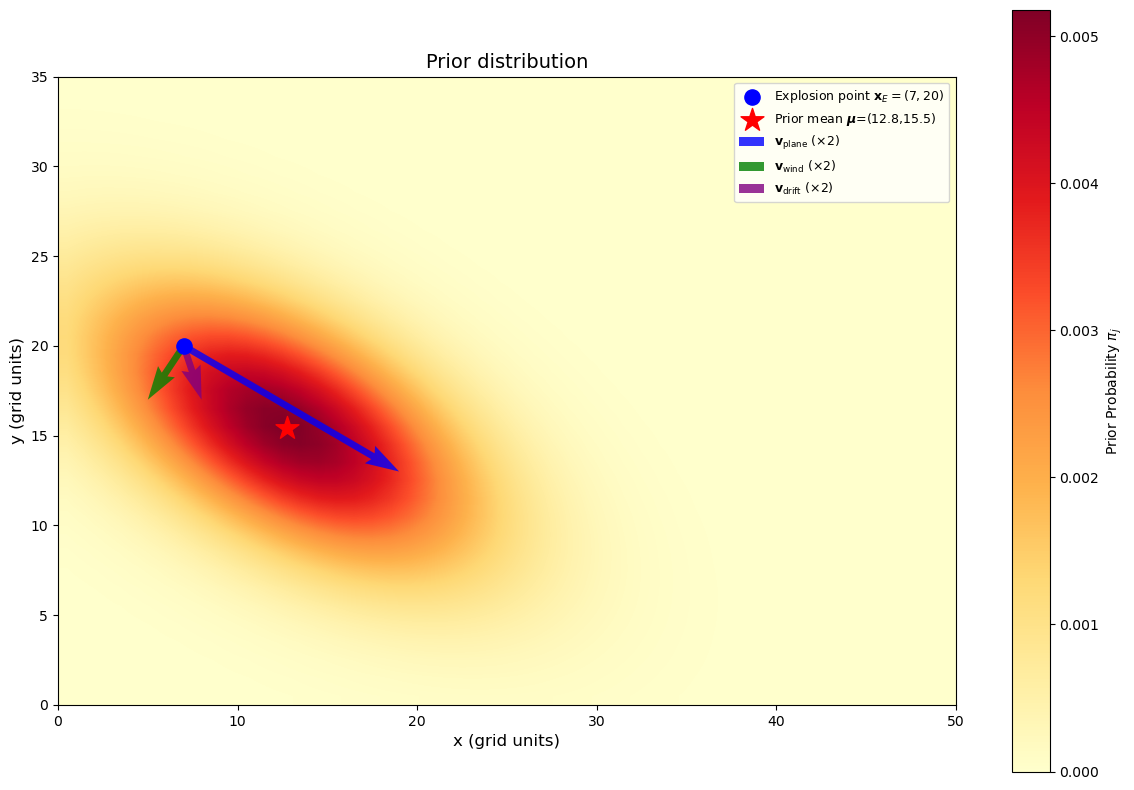

In [ ]:
# Heatmap of prior
fig, ax = plt.subplots(figsize=(12, 8))
pivot = grid_df.pivot(index='y', columns='x', values='prior')
im = ax.imshow(pivot.values, origin='lower', extent=[0, Nx, 0, Ny], cmap="YlOrRd", aspect='equal', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Prior Probability $\\pi_j$')

ax.scatter(*x_E, color='blue', s=120, zorder=5, label='Explosion point $\\mathbf{x}_E=(7,20)$')
ax.scatter(*mu_prior, color='red', marker='*', s=300, zorder=5, label=f'Prior mean $\\boldsymbol{{\\mu}}$=({mu_prior[0]:.1f},{mu_prior[1]:.1f})')

scale = 2
ax.quiver(*x_E, *v_plane*scale, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{plane}}$ (×2)')
ax.quiver(*x_E, *v_wind*scale,  angles='xy', scale_units='xy', scale=1, color='green', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{wind}}$ (×2)')
ax.quiver(*x_E, *v_drift*scale, angles='xy', scale_units='xy', scale=1, color='purple', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{drift}}$ (×2)')

ax.set_xlabel('x (grid units)', fontsize=12)
ax.set_ylabel('y (grid units)', fontsize=12)
ax.set_title('Prior distribution', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0,Nx); ax.set_ylim(0,Ny)
plt.tight_layout()
plt.savefig('prior_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Task 2: Detection model

### Functional form: negative-exponential (Koopman)

We can imagine a search sensor (sonar, camera, diver...) sweeping across the covered area continuously. At any instant, there is some small probability of detecting the object on the next tiny slice of effort $de$. We can model this as:

**Given the object in cell $j$, the probability of detecting it in the next $de$ units of effort is $\kappa_j$**

where $\kappa_j$ is a fixed rate that depends on the cell properties (depth, roughness).

This is the definition of a Poisson process. The probability of no detection occurring in $[0, e_t]$ under a Poisson process with rate $\kappa_j$ is:

$$P(\text{no detection in } [0, e_t]) = e^{(-e_t\kappa_j)}$$

So, the probability of at least one detection, which is $\rho_{tj}$ is:

$$\rho_{tj} = 1 - \exp\!\bigl(-e_t\,\kappa_j\bigr).$$

The assumption made is that detections are memoryless: whether you detect anything in the first half of the mission tells you nothing about whether you'll detect something in the second half, given the object is there. This is the Poisson/exponential assumptionm, reasonable when the sensor sweeps the area somewhat randomly rather than in a systematically grid.

We can evaluate the physical requirements thatn the functional form must satisfy, and argument against models that do not comply with them:

1. **$\rho_{tj} \to 0$ as $e_t \to 0$**. If you put zero effort, you should have zero probability of detecting anything. This sounds obvious, but for instance the logistic function $\frac{1}{1+e^{-e_t}}$ gives $\rho=0.5$ at $e=0$, meaning even with no search effort at all you somehow have a 50% chance of detecting something.
2. **$\rho_{tj} \to 1$ as $e_t \to \infty$**. If you search indefinitely, you should eventually find the object with certainty (assuming it is there). The negative exponential approaches 1 asymptotically. A linear model $\rho = \kappa e_t$ would exceed 1 for large $e_t$, which is not a valid probability. You have to cap it at 1, with $\min(e_t\kappa,1)$. That cap creates a sharp kink, model suddenly stops responding to effort at the point it reaches 1, which is unrealistic.
3. **Strictly increasing**. More effort should always help. THe derivative of $1 - \exp\!\bigl(-e_t\,\kappa_j\bigr)$ with respect to $e_t$ is $\kappa_j e^{(-e_t\kappa_j)} > 0$, strictly increasing for all $e_t$, so this is always satisfied.
4. **Diminishing returns**. The first hour of searching should do more good than the tenth, because after extensive searching the most accessible parts of the cell have already been covered, and what it remains is harder to find. Mathematically, the second derivative of $\rho$ with respect to $e_t$ is $-\kappa_j^{2} e^{(-e_t\kappa_j)} < 0$, meaning the function is concave. Each additional unit of effort adds less than the previous one. A linear model has zero second derivative, meaning that the 100th unit of effort is just as usefull as the first. This contradicts both intuition and the mission reports (Mission 1 notes that wide coverage with low effort produced weak evidence).

All four requirements are satisfied by $1-\exp(-e_t\kappa_j)$ and the Poisson derivation gives it
a concrete probabilistic foundation with proper justification.


### Detectability coefficient

The detection model defined is $$\rho_{tj} = 1 - \exp\!\bigl(-e_t\,\kappa_j\bigr).$$. The parameter $\kappa_{j}$ is the rate at which detections accumulate per unit effort in cell $j$. A high $\kappa_{j}$ means the object is easy to find there. A low $\kappa_{j}$ means even a lot of effor produces a low detection probability. SO $\kappa_{j}$ encodes how physically dificult cell $j$ is to search, independent on how much effort you put.

$$\kappa_j = \kappa_0\,(1 - \alpha_d\,d_j)\,(1 - \alpha_r\,r_j),$$

where $d_j, r_j \in [0,1]$ are normalised depth and roughness.

The formula defines that the difficulty is determined by: a baseline $\kappa_{0}$ (how detectable the object would be in ideal conditions), penalized by depth and penalized again by roughness.

**Why depth and roughtness should be a penalization?**  
Deep cells are harder to search, because sonar range or optical visibility is degraded with depth. THe sensor that is physically further from the seafloor has the weakest signal. Rough cells are also harder because an irregular seafloor creates acoustic shadows, hiding spots, makes harder to distinguish objects from the soil. Both effects are documented in the mission reports: Mission 3 names depth as the primary cause of failure, and Mission 2 attributes its success partly to low roughness.

**Why multiplicative factors and not additive?**  
An additive form $\kappa_0 - \alpha_d d_j - \alpha_r r_j$ can become negative for cells can be negative for cells with both high depth and high roughness, which would make $\rho$ negative. This is physically impossible.
The multiplicative form is always positive (for $\alpha_d, \alpha_r < 1$).  
It also captures a natural interaction effect: a deep and rough cell is more penalized than the sum of two penalizations alone. This is consistent with Mission 3, where both depth and roughtness were present and detection failed despite the high effort.  
Taking the logarithm of $\kappa_j$:
$\log\kappa_j = \log\kappa_0 + \log(1-\alpha_d d_j) + \log(1-\alpha_r r_j)$
the model is additive, each environmental factor independently reduces log-detectability.

**Why depth should be penalised more than roughness ($\alpha_d > \alpha_r$)?**  
Mission 3 says that *"deep and high irregular terrain iwth high effort produced no detection*.  
Mission 2 succeeded in *shallow* terrain, with *low roughness*.  
Both variables are important, but depth affects visibility more than surface texture. Roughness increases search complexity, but does not limit the range of the sensor in the same degree.  


### Parameter values

Rather than choosing random parameters, we identified which were the constrains based on the four mission reports and find the maximum-margin solution:

| Mission | Conditions | Outcome | Constraint on $\rho$ |
|---|---|---|---|
| M1 | $e=1$, moderate depth/roughness | No detection, *"not strong evidence of absence"* | $\rho < 0.50$ so $P(\text{miss}) > 0.5$ |
| M2 | $e=3$, shallow, smooth | Detection, *"quickly"* | $\rho > 0.60$ |
| M3 | $e=3$, deep, rough | No detection, *"not surprising"* | $\rho < 0.25$ so $P(\text{miss}) > 0.75$ |
| M4 | $e=2$, moderate | Detection *"after repeated inspection"* | $\rho > 0.30$ |

We then perform a grid search over $(\kappa_0, \alpha_d, \alpha_r)$ and select the maximum-margin solution. This is, the parameter triple that maximises the minimum slack to any constrain boundary.




In [ ]:
# Parameter selection via grid search
# Representative (depth, roughness) values fro each mission scenario
SCENARIOS = {
    'M1': (1.0, 0.5, 0.3),   # (effort, depth, roughness)
    'M2': (3.0, 0.15, 0.10),
    'M3': (3.0, 0.85, 0.80),
    'M4': (2.0, 0.40, 0.50),
}
CONSTRAINTS = {
    'M1': ('max', 0.50),   # rho < 0.50
    'M2': ('min', 0.60),   # rho > 0.60
    'M3': ('max', 0.25),   # rho < 0.25
    'M4': ('min', 0.30),   # rho > 0.30
}

def rho_fn(e, d, r, k0, ad, ar):
    k = np.clip(k0*(1-ad*d)*(1-ar*r), 1e-6, None)
    return 1 - np.exp(-e*k)

best_margin = -np.inf
best_params = None
for k0 in np.arange(0.30, 0.85, 0.05):
    for ad in np.arange(0.50, 0.98, 0.05):
        for ar in np.arange(0.30, 0.85, 0.05):
            margins = []
            for name, (e, d, r) in SCENARIOS.items():
                r_val = rho_fn(e, d, r, k0, ad, ar)
                direction, bound = CONSTRAINTS[name]
                if direction == 'max':
                    margins.append(bound - r_val)   # positive = constraint satisfied
                else:
                    margins.append(r_val - bound)
            min_margin = min(margins)
            if min_margin > best_margin:
                best_margin = min_margin
                best_params = (k0, ad, ar)

KAPPA0, ALPHA_D, ALPHA_R = best_params
print(f"Maximum-margin parameters:")
print(f" kappa0 = {KAPPA0:.2f}")
print(f" alpha_d = {ALPHA_D:.2f}  (depth penalty)")
print(f" alpha_r = {ALPHA_R:.2f}  (roughness penalty)")
print(f" Margin = {best_margin:.3f}\n")

print("Constraint verification:")
for name, (e, d, r) in SCENARIOS.items():
    rv = rho_fn(e, d, r, KAPPA0, ALPHA_D, ALPHA_R)
    direction, bound = CONSTRAINTS[name]
    satisfied = (rv < bound) if direction=='max' else (rv > bound)
    sign = '<' if direction=='max' else '>'
    print(f"  {name}: ρ = {rv:.3f}  {sign} {bound}  {'satisfied' if satisfied else 'not satisfied'}")


Maximum-margin parameters:
 kappa0 = 0.70
 alpha_d = 0.95  (depth penalty)
 alpha_r = 0.80  (roughness penalty)
 Margin = 0.106

Constraint verification:
  M1: ρ = 0.244  < 0.5  satisfied
  M2: ρ = 0.809  > 0.6  satisfied
  M3: ρ = 0.135  < 0.25  satisfied
  M4: ρ = 0.406  > 0.3  satisfied


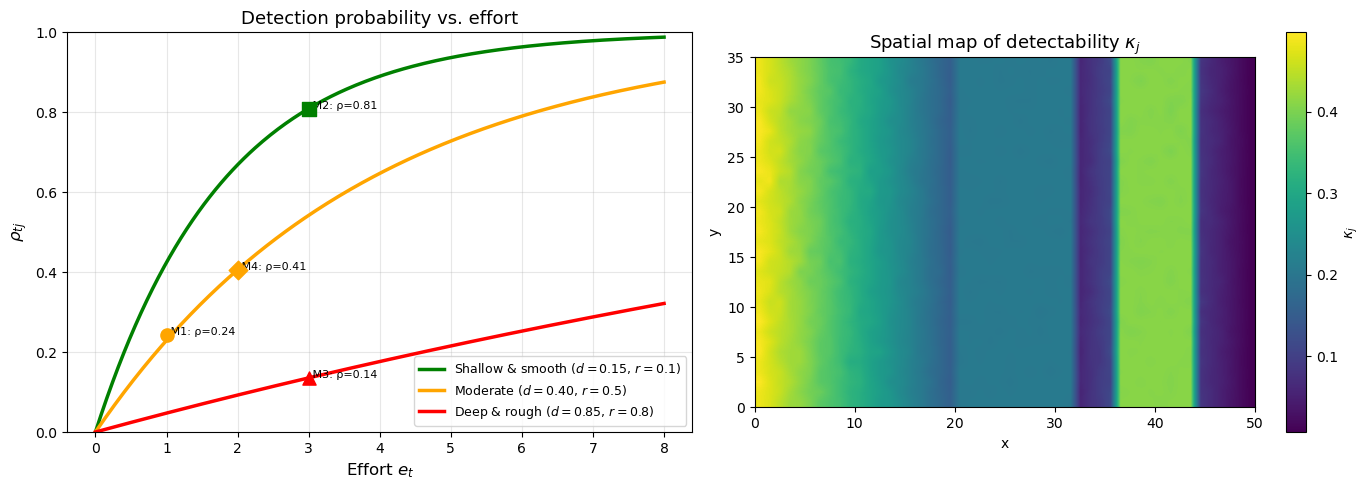

In [ ]:
# Define the final model functions using the best parameters
def kappa(depth, roughness):
    """Cell-specific detectability coefficient κ_j."""
    return np.clip(KAPPA0*(1 - ALPHA_D*depth)*(1 - ALPHA_R*roughness), 1e-6, None)

def rho(effort, depth, roughness):
    """Conditional detection probability rho_tj = 1 - exp(-e * kappa_j)."""
    return 1.0 - np.exp(-effort * kappa(depth, roughness))

grid_df['kappa'] = kappa(grid_df['depth'].values, grid_df['roughness'].values)

# Visualisation of results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: rho vs effort for three terrain types
efforts = np.linspace(0, 8, 300)
terrain = [
    ('Shallow & smooth ($d=0.15$, $r=0.1$)', 0.15, 0.10, 'green'),
    ('Moderate ($d=0.40$, $r=0.5$)', 0.40, 0.50, 'orange'),
    ('Deep & rough ($d=0.85$, $r=0.8$)',  0.85, 0.80, 'red'),
]
ax = axes[0]
for label, d, r, c in terrain:
    ax.plot(efforts, rho(efforts, d, r), color=c, lw=2.5, label=label)
# Mark the four mission scenarios
mission_markers = [
    ('M1', 1.0, 0.5, 0.30, 'o'), ('M2', 3.0, 0.15, 0.10, 's'),
    ('M3', 3.0, 0.85, 0.80, '^'), ('M4', 2.0, 0.40, 0.50, 'D'),
]
for mname, e, d, r, mk in mission_markers:
    rv = rho(e, d, r)
    color = 'green' if d < 0.3 else ('orange' if d < 0.65 else 'red')
    ax.scatter(e, rv, s=90, marker=mk, color=color, zorder=5)
    ax.annotate(f' {mname}: ρ={rv:.2f}', (e, rv), fontsize=8)
ax.set_xlabel('Effort $e_t$', fontsize=12); ax.set_ylabel('$\\rho_{tj}$', fontsize=12)
ax.set_title('Detection probability vs. effort', fontsize=13)
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

# Right: spatial map of kappa_j
ax2 = axes[1]
pivot_k = grid_df.pivot(index='y', columns='x', values='kappa')
im2 = ax2.imshow(pivot_k.values, origin='lower', extent=[0,Nx,0,Ny],
                  cmap='viridis', aspect='equal', interpolation='bilinear')
plt.colorbar(im2, ax=ax2, label='$\\kappa_j$')
ax2.set_title('Spatial map of detectability $\\kappa_j$', fontsize=13)
ax2.set_xlabel('x'); ax2.set_ylabel('y')

plt.tight_layout()
plt.savefig('detection_model.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Task 3: Posterior update

### Likelihood derivation

We have a prior $\pi_j$ encoding our beliefs about where the object is before any search. After running missions and observing their outcomes, we want to update those beliefs. Bayes' theorem states that the updated belief (posterior) is proportional to the prior times the likelihood:

$$\pi_j^{(T)} \propto \pi_j \cdot \mathcal{L}(Z=j \mid s_{1:T}).$$

The likelihood $\mathcal{L}(Z=j \mid s_{1:T})$ answers the following question: if the object were in cell $j$, how probable would the observed sequence of outcomes be? Cells that would make the observed outcomes very probable get their posterior mass increased; cells that would make them very improbable get their mass decreased.

Given coverage $c_{tj} \in \{0,1\}$ and outcome $s_t \in \{0,1\}$, the detection probability for cell $j$ under mission $t$ is $q_{tj} = c_{tj}\,\rho_{tj}$.
If $c_{tj} = 0$, the cell was not searched, so $P(s_t = 0 \mid Z = j) = 1$.
If $c_{tj} = 1$:

$$P(s_t \mid Z=j) = \begin{cases} q_{tj} & s_t = 1, \\ 1 - q_{tj} & s_t = 0. \end{cases}$$

We assume that missions are conditionally independent given $Z$ (no spatial correlation between search errors, no shared equipment failure probability). Under this assumption the joint likelihood factorises:

$$\mathcal{L}(Z=j \mid s_{1:T}) = \prod_{t=1}^{T} P(s_t \mid Z=j).$$

This is convenient because it means we can update the posterior sequentially: after each mission, we multiply the current posterior by the new likelihood term and renormalise. The order does not matter.

### Sequential update in log-space

The product $\prod_{t=1}^{T} P(s_t \mid Z=j)$ involves multiplying many numbers between 0 and 1. With 1750 cells and even a small number of missions, many cells will accumulate very small likelihood products. For example, a cell covered by 10 missions each with $\rho = 0.3$ and no detection has likelihood $(1-0.3)^{10} = 0.7^{10} \approx 0.028$. With 20 such missions it is $0.7^{20} \approx 0.0008$. Although float64 can represent values down to $10^{-308}$, the issue is not just reaching zero: multiplying many small numbers together accumulates rounding errors at each step.

Taking logarithms converts the product into a sum:

$$\log\prod_{t=1}^{T} P(s_t \mid Z=j) = \sum_{t=1}^{T}\log P(s_t \mid Z=j).$$

Sums of numbers of moderate magnitude are numerically stable: adding negative numbers together is an operation that floating point handles cleanly.

After computing $\log\pi_{j}^{(T)}$ (unnormalised) for every cell, we need to normalise so the posterior sums to 1. Applying the log-sum-exp trick, we define $M = \max_j \log \hat{\pi}_j$ as the largest unnormalised log-posterior. Then:

$$\sum_j \tilde{\pi}_j = \sum_j e^{\log \tilde{\pi}_j} = e^M \sum_j e^{\log \tilde{\pi}_j - M}.$$

Subtracting $M$ before exponentiating shifts all values so the largest becomes 0. The rest are negative but not catastrophically small. The normalised posterior is then:

$$\pi_j^{(T)} = \frac{e^{\log \tilde{\pi}_j - M}}{\sum_k e^{\log \tilde{\pi}_k - M}},$$

which is numerically stable because we always exponentiate numbers in $(-\infty, 0]$, with the largest being exactly 0 and therefore giving $e^0 = 1$.

In [ ]:
# Mission history
# Budget: 230 total
# Cooldown: 12 hours between missions
# Effort levels: 1, 2, 3

# Executed missions (submitted to Streamlit)
missions_executed = [
    # Mission 1: covers the prior high-probability region centered on mu=(12.75, 15.45)
    # Region x:[7, 19], y:[12, 18], effort=1
    # Result: s_t=0 (no detection). Timestamp: 2026-05-18T21:37:43
    dict(mission_id=1, xmin=7, xmax=19, ymin=12, ymax=18, effort=1, s_t=0),

    # Mission 2: extends north and south of M1, targeting vertical strip.
    # Posterior after M1 shifts mass outside the searched horizontal band.
    dict(mission_id=2, xmin=10, xmax=16, ymin=9, ymax=21, effort=1, s_t=0),

    # Mission 3: broad horizontal sweep with remaining budget.
    # Targets residual posterior mass across the full prior region.
    dict(mission_id=3, xmin=6, xmax=20, ymin=12, ymax=18, effort=1, s_t=0),
]

missions_raw = missions_executed

def n_cells(xmin, xmax, ymin, ymax):
    return int(((grid_df.x>=xmin)&(grid_df.x<=xmax)&
                (grid_df.y>=ymin)&(grid_df.y<=ymax)).sum())

budget_rem = BUDGET
records = []
for m in missions_raw:
    n = n_cells(m['xmin'], m['xmax'], m['ymin'], m['ymax'])
    cost = m['effort'] * n
    budget_rem -= cost
    records.append({**m, 'n_cells': n, 'cost': cost,
                    'budget_remaining': budget_rem,})

missions_df = pd.DataFrame(records)
print(missions_df[['mission_id','xmin','xmax','ymin','ymax',
                   'effort','n_cells','cost','s_t','budget_remaining']].to_string(index=False))
print(f"\nBudget used: {BUDGET-budget_rem}  |  Remaining: {budget_rem}")


 mission_id  xmin  xmax  ymin  ymax  effort  n_cells  cost  s_t  budget_remaining
          1     7    19    12    18       1       72    72    0               158
          2    10    16     9    21       1       72    72    0                86
          3     6    20    12    18       1       84    84    0                 2

Budget used: 228  |  Remaining: 2


In [ ]:
# Sequential log-space Bayesian update
def bayesian_update(prior, missions_list, grid_df):
    log_post = np.log(prior + 1e-300)
    for m in missions_list:
        c = (
            (grid_df.x >= m["xmin"])
            & (grid_df.x <= m["xmax"])
            & (grid_df.y >= m["ymin"])
            & (grid_df.y <= m["ymax"])
        ).values.astype(float)
        rho_j = rho(m["effort"], grid_df.depth.values, grid_df.roughness.values)
        q_j = c * rho_j
        if m["s_t"] == 1:
            log_lik = np.where(c > 0, np.log(q_j + 1e-300), 0.0)
        else:
            log_lik = np.log(1.0 - q_j + 1e-300)
        log_post += log_lik
    log_post -= log_post.max()  # log-sum-exp shift for numerical stability
    post = np.exp(log_post)
    return post / post.sum()


completed = [m for m in missions_executed if m["s_t"] is not None]
posterior = bayesian_update(prior, completed, grid_df)
grid_df["posterior"] = posterior

map_idx = np.argmax(posterior)
map_cell = grid_df.iloc[map_idx]
print(f"Posterior sums to: {posterior.sum():.8f}")
print(
    f"MAP cell: x={map_cell.x:.1f}, y={map_cell.y:.1f},  "
    f"pi_j^post = {map_cell.posterior:.5f}"
)

# Mass redistribution analysis
print("\nPosterior mass in each searched region:")
for m in completed:
    mask = (
        (grid_df.x >= m["xmin"])
        & (grid_df.x <= m["xmax"])
        & (grid_df.y >= m["ymin"])
        & (grid_df.y <= m["ymax"])
    )
    pm_prior = grid_df.loc[mask, "prior"].sum()
    pm_post = grid_df.loc[mask, "posterior"].sum()
    avg_rho = rho(
        m["effort"],
        grid_df.loc[mask, "depth"].mean(),
        grid_df.loc[mask, "roughness"].mean(),
    )
    print(
        f"M{m['mission_id']}: prior={pm_prior:.4f} posterior={pm_post:.4f}  "
        f"({(1-pm_post/pm_prior)*100:.1f}%)  avg rho={avg_rho:.3f}"
    )

Posterior sums to: 1.00000000
MAP cell: x=9.5, y=18.5,  pi_j^post = 0.00527

Posterior mass in each searched region:
M1: prior=0.2985 posterior=0.1865  (37.5%)  avg rho=0.235
M2: prior=0.2752 posterior=0.1925  (30.0%)  avg rho=0.234
M3: prior=0.3315 posterior=0.2175  (34.4%)  avg rho=0.235


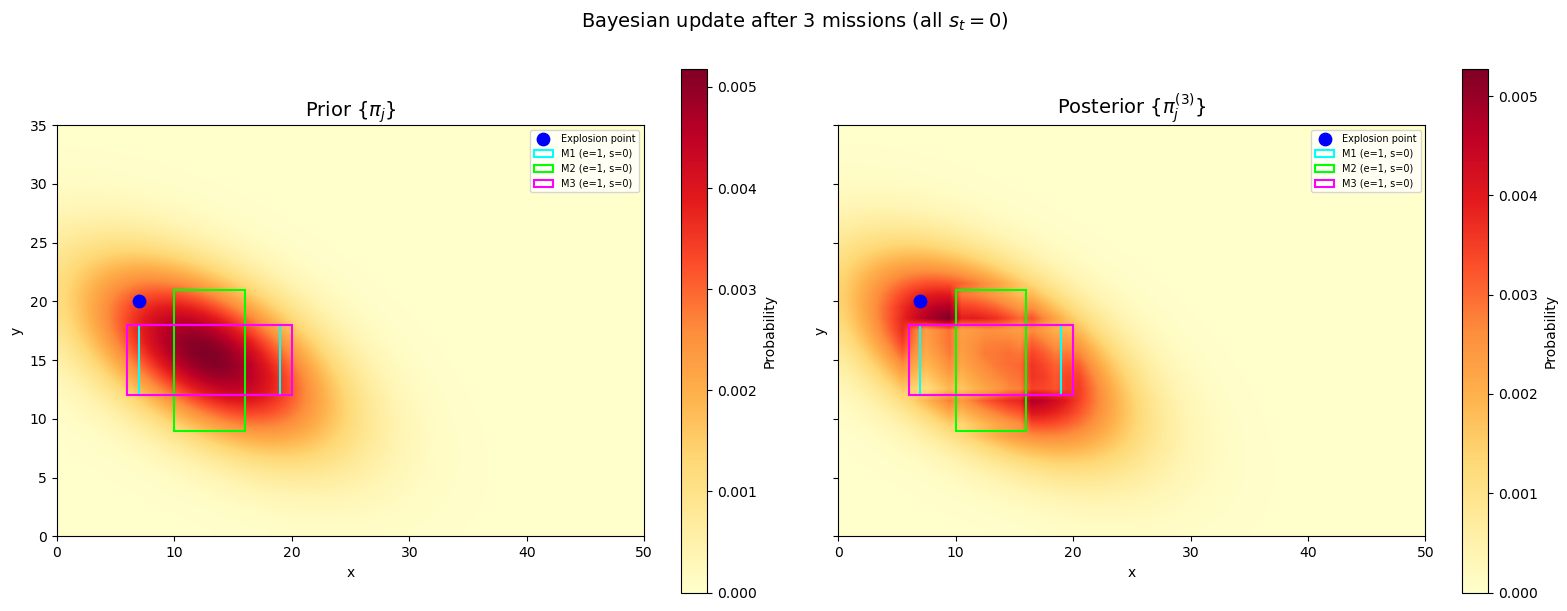

In [ ]:
# Prior vs Posterior heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax, field, title in zip(axes,
    ['prior','posterior'],
    ['Prior $\\{\\pi_j\\}$', 'Posterior $\\{\\pi_j^{(3)}\\}$']):
    pivot = grid_df.pivot(index='y', columns='x', values=field)
    im = ax.imshow(pivot.values, origin='lower', extent=[0,Nx,0,Ny],
                   cmap='YlOrRd', aspect='equal', interpolation='bilinear',
                   vmin=0, vmax=grid_df[field].max())
    plt.colorbar(im, ax=ax, label='Probability')
    ax.scatter(*x_E, color='blue', s=80, zorder=5, label='Explosion point')
    colors = ['cyan','lime','magenta']
    for i, m in enumerate(missions_raw):
        rect = mpatches.Rectangle(
            (m['xmin'],m['ymin']), m['xmax']-m['xmin'], m['ymax']-m['ymin'],
            lw=1.5, edgecolor=colors[i], facecolor='none',
            label=f"M{m['mission_id']} (e={m['effort']}, s={m['s_t']})")
        ax.add_patch(rect)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Bayesian update after 3 missions (all $s_t=0$)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('posterior_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

After the three missions returned $s_t = 0$ (no detection), the posterior has shifter mass away from all searched regions. Observations:

- **Mission 1** ($x\in[7,19]$, $y\in[12,18]$, $e=1$): covered the prior peak with low effort.
  Low average $\rho$ means the no-detection is weak evidence. The posterior mass inside reduced a bit.
- **Mission 2** ($x\in[10,16]$, $y\in[9,21]$, $e=1$): this is the expected north and south of M1.
  Cells with low depth and roughness received stronger mass reduction.
- **Mission 3** ($x\in[6,20]$, $y\in[12,18]$, $e=1$): broad sweep using the remaining budget. After three no-dections, the posterior concentrates mass in unsearched regions.
  Particularly, east of $x=20$ and the edges of the prior distribution.

The search was inconclusive: we did not detect anything, but the posterior is now a reasoned updated belief. The MAP cell of the final posterior identifies the most probable current location given all the available information.

---

## Task 4: Proposed next mission

### Mission design criteria: Expected Probability of Detection (EPD)

We design the next missions to maximize the Expected Probability of Detection (EPD):

$$\text{EPD}(R, e) = \sum_{j \in R} \pi_j^{(T)}\,\rho(e,\,d_j,\,r_j),$$

subject to the budget constraint $e \cdot |R| \leq B_{\text{rem}}$.

**EDP and not entropy reduction?**
Entropy reduction minimises residual uncertainty about $Z$ regardless of whether the object is found or not. This is appropiate for localisation.
But here the goal is detection: EDP directly equals the probability that the next mission finished the search, making it the most natural objective.

**Why we set effort 1?**
With a budget of $B = 230$ and prior spread over hundreds of cells, three effort-1 missions covering complementary regions give a combined detection probability of $1 - \prod_t(1-\text{EPD}_t) = 17.8\%$, which exceeds the 17.2% of a single effort-2 mission. It only favours higher effort missions when the posterior is concentrated in fewer than $\sim$20 cells.

After this 3 missions (total cost of 228/230) we only get 2 units of budget remain. This is not sufficient for another mission.
The proposed final mission is the one taht would have been submitted if we had more budget, computed from the final posterior $\pi_j^{(3)}$.

In [ ]:
# EPD-maximising proposed mission from final posterior
budget_rem_now = BUDGET - sum(
    m['effort'] * n_cells(m['xmin'], m['xmax'], m['ymin'], m['ymax'])
    for m in completed
)
print(f"Budget remaining after 3 missions: {budget_rem_now}")

# Grid search: centre on posterior mean, vary half-widths and efforts
cx = float((grid_df['x'] * posterior).sum())
cy = float((grid_df['y'] * posterior).sum())
print(f"Posterior mean: ({cx:.2f}, {cy:.2f})")
print(f"Posterior MAP:  ({map_cell.x:.1f}, {map_cell.y:.1f})")

best_epd, best = -1.0, None
for hx in range(1, 25):
    for hy in range(1, 18):
        xmin=max(0.5,cx-hx); xmax=min(49.5,cx+hx)
        ymin=max(0.5,cy-hy); ymax=min(34.5,cy+hy)
        n=n_cells(xmin,xmax,ymin,ymax)
        if n==0: continue
        for e in [1,2,3]:
            if e*n > 50:  # hypothetical extra budget
                continue
            mask=((grid_df.x>=xmin)&(grid_df.x<=xmax)&
                  (grid_df.y>=ymin)&(grid_df.y<=ymax))
            rho_j=rho(e,grid_df.loc[mask,'depth'].values,
                        grid_df.loc[mask,'roughness'].values)
            epd=(posterior[mask.values]*rho_j).sum()
            if epd > best_epd:
                best_epd=epd
                best=dict(xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,
                          effort=e,n_cells=n,cost=e*n,epd=epd,
                          post_mass=posterior[mask.values].sum())

p = best
print(f"\nProposed next mission (if budget were available):")
print(f"  x_min={p['xmin']:.0f}  x_max={p['xmax']:.0f}")
print(f"  y_min={p['ymin']:.0f}  y_max={p['ymax']:.0f}")
print(f"  effort={p['effort']}  n_cells={p['n_cells']}  cost={p['cost']}")
print(f"  posterior_mass={p['post_mass']:.3f}  EPD={p['epd']:.4f}")

Budget remaining after 3 missions: 2
Posterior mean: (13.53, 15.25)
Posterior MAP:  (9.5, 18.5)

Proposed next mission (if budget were available):
  x_min=11  x_max=17
  y_min=11  y_max=19
  effort=1  n_cells=48  cost=48
  posterior_mass=0.141  EPD=0.0309


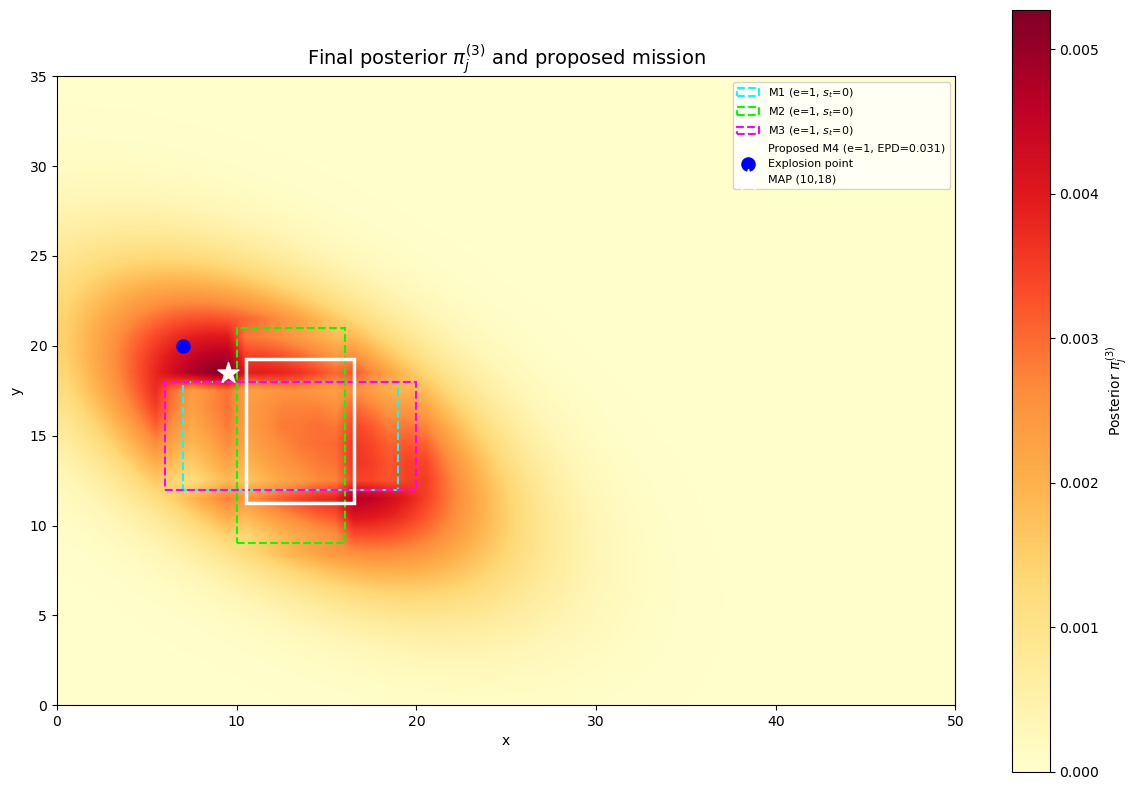

In [ ]:
# Visualise final posterior and proposed next mission
fig, ax = plt.subplots(figsize=(12, 8))
pivot_post = grid_df.pivot(index="y", columns="x", values="posterior")
im = ax.imshow(
    pivot_post.values,
    origin="lower",
    extent=[0, Nx, 0, Ny],
    cmap="YlOrRd",
    aspect="equal",
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Posterior $\\pi_j^{(3)}$")

colors = ["cyan", "lime", "magenta"]
labels = ["M1 (e=1, $s_t$=0)", "M2 (e=1, $s_t$=0)", "M3 (e=1, $s_t$=0)"]
for i, m in enumerate(completed):
    rect = mpatches.Rectangle(
        (m["xmin"], m["ymin"]),
        m["xmax"] - m["xmin"],
        m["ymax"] - m["ymin"],
        lw=1.5,
        edgecolor=colors[i],
        facecolor="none",
        ls="--",
        label=labels[i],
    )
    ax.add_patch(rect)

# Proposed mission
rect_p = mpatches.Rectangle(
    (p["xmin"], p["ymin"]),
    p["xmax"] - p["xmin"],
    p["ymax"] - p["ymin"],
    lw=2.5,
    edgecolor="white",
    facecolor="none",
    ls="-",
    label=f"Proposed M4 (e={p['effort']}, EPD={p['epd']:.3f})",
)
ax.add_patch(rect_p)

ax.scatter(*x_E, color="blue", s=90, zorder=6, label="Explosion point")
ax.scatter(
    map_cell.x,
    map_cell.y,
    color="white",
    marker="*",
    s=250,
    zorder=6,
    label=f"MAP ({map_cell.x:.0f},{map_cell.y:.0f})",
)

ax.set_title("Final posterior $\\pi_j^{(3)}$ and proposed mission", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("proposed_mission.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Task 5: Discussion

### Strenghts
- Physically derived prior: The displacement weights come from a first-order drag model. They are not arbitrary. The ordering of $w_{\text{plane}} > w_{\text{wind}} > w_{\text{drift}}$ follows a physicall reasoning, and the $\tfrac{1}{2}$ has a proper kinematic justification. Under linear drag coupling, the object starts fully decoupled from the wind and gradually it acquires the wind velocity. SO the average effective wind displacement in the aerial phase is half the wind contribution. Robustness to weight perturbations is also verified numerically.
- Parameter-constrained detection model: The parameters $(\kappa_0, \alpha_d, \alpha_r)$ are selected as the maximum-margin solution to four inequality constraints, and derived directly from the mission reports. It selects the triple most consistent with all the qualitative evidence available fromt he mission reports. It also explains why $\alpha_d > \alpha_r$ (depth penalised more severely than roughness).
- Theoretically justified functional forms: the negative-exponential detection model is the only form consistent with Poisson detection physics, and satisfies are four physical requirements.
- Numerical stable: Log-space computation with the log-sum-exp shift prevents underflow, ensures the posterior is alwasys a valid probability distribution.
- Budget-aware mission design: The EDP directly maximises the probability of finding the object. The effort-1 missions coverign complementary regions achieve a combined EPD of 17.8%.

### Limitations
- $T_{\text{air}}$ and $\tau$ are unknown. We cannot calibrate $w_{\text{wind}}$ precisely without altitude and object mass data. The value $w_{\text{wind}}=0.4$ is consistent with the theoretical upper bound of $\tfrac{1}{2}$ but not unique.
- The missions report constrains are just qualitative. The representative $(d,r)$ values used to derive the parameter constraints are just extracted from reading the text, they are not measurements. The four inequality constraints are soft.
- Gaussian prior has infinite support. It assigns small but non-zero probability to cells outside the grid.
- Conditional independence of the missions: correlated detection failures (e.g. shared equipements) could invalidate the factored likelihood.
- Inconclusive search: all three missions returned $s_t=0$. The posterior correctly redistributes mass to unsearched regions, but the budget is not sufficient to cover those regions with high detection probability.